In [481]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd 

In [482]:
#Amount of data point
N = 20 

#Random points on X axis (-5, 5)
X = np.random.random(N)*10 - 5

#Line with noise
Y = .5 *  - 1 + np.random.random(N)

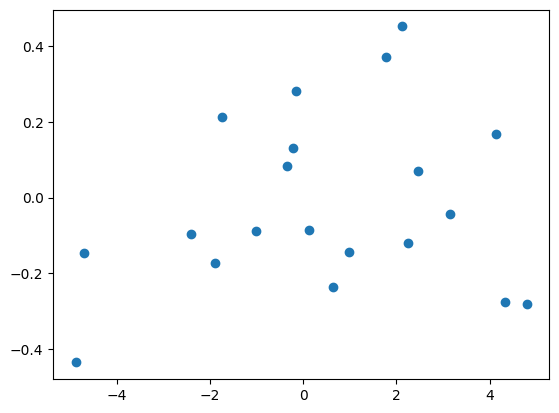

In [483]:
#Graph
plt.scatter(X,Y)

In [484]:
#Create the model
model = nn.Linear(1,1)

#Loss and optimizers
criterion = nn.MSELoss()
optimizers = torch.optim.SGD(model.parameters(), lr=0.1)

#If data points are in numpy there is a need to change them to tensors
X = X.reshape(N,1)
Y = Y.reshape(N,1)

input = torch.from_numpy(X.astype(np.float32))
target = torch.from_numpy(Y.astype(np.float32))
print(f'Type of inputs: {type(input)}')
print(f'Type of outputs: {type(target)}')

Type of inputs: <class 'torch.Tensor'>
Type of outputs: <class 'torch.Tensor'>


In [485]:
#Train loop

epochs = 30 
losses = []

for i in range(epochs):
    optimizers.zero_grad()
    
    #Forward pass
    output = model(input)
    loss = criterion(output, target)
    
    #Keep losses to check if the model learns
    losses.append(loss.item())
    
    #Backward and optimize
    loss.backward()
    optimizers.step()
    
    print(f'Epoch {i+1}/{epochs}, Loss: {loss.item(): 4f}')
    
    
    

Epoch 1/30, Loss:  0.756095
Epoch 2/30, Loss:  0.352157
Epoch 3/30, Loss:  0.208522
Epoch 4/30, Loss:  0.143889
Epoch 5/30, Loss:  0.108798
Epoch 6/30, Loss:  0.087643
Epoch 7/30, Loss:  0.074279
Epoch 8/30, Loss:  0.065678
Epoch 9/30, Loss:  0.060102
Epoch 10/30, Loss:  0.056477
Epoch 11/30, Loss:  0.054119
Epoch 12/30, Loss:  0.052584
Epoch 13/30, Loss:  0.051585
Epoch 14/30, Loss:  0.050934
Epoch 15/30, Loss:  0.050511
Epoch 16/30, Loss:  0.050235
Epoch 17/30, Loss:  0.050055
Epoch 18/30, Loss:  0.049938
Epoch 19/30, Loss:  0.049862
Epoch 20/30, Loss:  0.049813
Epoch 21/30, Loss:  0.049780
Epoch 22/30, Loss:  0.049759
Epoch 23/30, Loss:  0.049746
Epoch 24/30, Loss:  0.049737
Epoch 25/30, Loss:  0.049731
Epoch 26/30, Loss:  0.049727
Epoch 27/30, Loss:  0.049725
Epoch 28/30, Loss:  0.049723
Epoch 29/30, Loss:  0.049722
Epoch 30/30, Loss:  0.049722


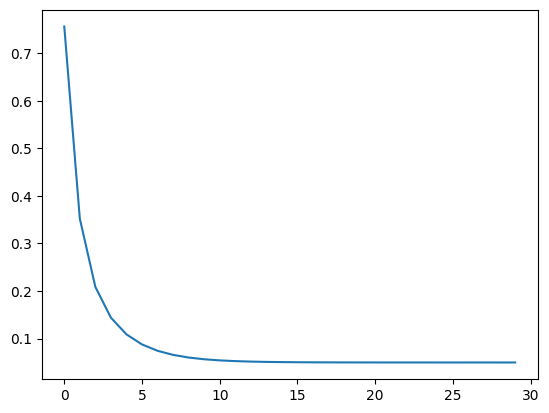

In [486]:
plt.plot(losses)

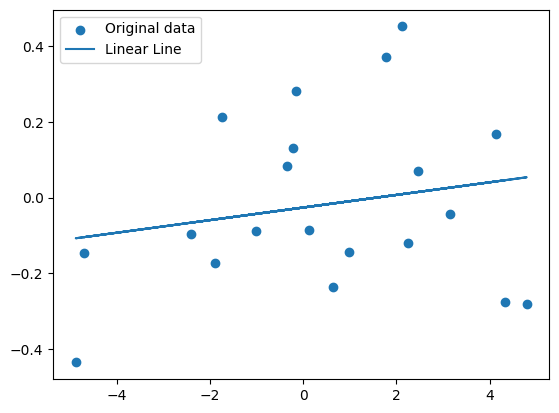

In [487]:
#Prediction
prediction = model(input).detach().numpy()
plt.scatter(X,Y, label = 'Original data')
plt.plot(X, prediction, label = 'Linear Line')
plt.legend()
plt.show()

Moore dataset Regression

In [488]:
import requests

url = 'https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv'
response = requests.get(url)

with open('moore.csv', 'wb') as f:
    f.write(response.content)

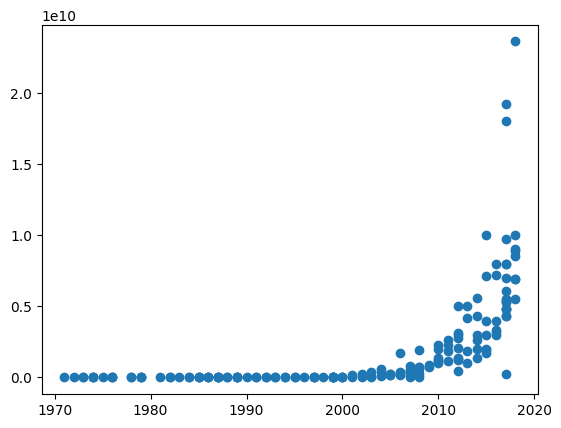

In [489]:
data = pd.read_csv('moore.csv', header=None).values
X = data[:, 0].reshape(-1,1)
Y = data[:,1].reshape(-1,1)
plt.scatter(X,Y)

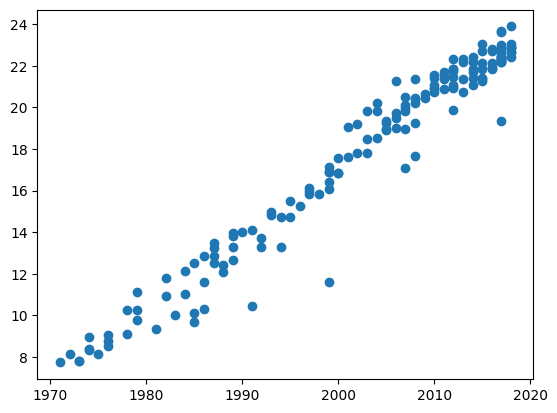

In [490]:
Y = np.log(Y)
plt.scatter(X,Y)

When training machine learning models (like linear regression or neural networks), it's often a good idea to normalize both the input (`X`) and target (`Y`) values.

---

### ✅ Benefits of Normalization

- **🚀 Faster Convergence**  
  Optimizers like gradient descent work more efficiently when features are on a similar scale.

- **🧠 Stable Training**  
  Prevents issues like exploding gradients or `NaN` losses, especially when inputs have very large or small values.

- **⚖️ Equal Feature Importance**  
  Ensures that all features contribute fairly to the model and none dominate just due to their scale.

- **📉 Better Numerical Performance**  
  Models tend to perform better when inputs are standardized with mean 0 and standard deviation 1.

- **👀 Clearer Visualization**  
  Makes it easier to spot trends when plotting, e.g., `plt.scatter(X, Y)` looks more centered and interpretable.

---

### 🧪 Normalization Formula:

```python
X = (X - X.mean()) / X.std()
Y = (Y - Y.mean()) / Y.std()

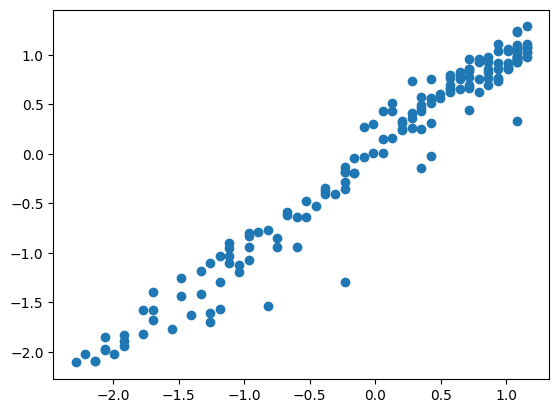

In [491]:
mx = X.mean()
sx = X.std()
my = Y.mean()
sy = Y.std()
X = (X - mx) / sx
Y = (Y - my) / sy
plt.scatter(X,Y)

In [492]:
#Data preprocessing
X = X.astype(np.float32)
Y = Y.astype(np.float32)

In [493]:
#Model preperation
model = nn.Linear(1,1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr= 0.01, momentum=0.7)

In [494]:
inputs = torch.from_numpy(X)
target = torch.from_numpy(Y)

In [495]:
epochs = 100
losses = []

for i in range (epochs):
    optimizer.zero_grad()
    
    #Forward pass
    outputs = model(inputs)
    loss = criterion(outputs, target)
    
    #Record losses
    losses.append(loss.item())
    
    #Backward
    loss.backward()
    optimizer.step()
    
    print(f'Epoch {i+1}/{epochs}, Loss: {loss.item(): 4f}')
    

Epoch 1/100, Loss:  2.522131
Epoch 2/100, Loss:  2.423778
Epoch 3/100, Loss:  2.263019
Epoch 4/100, Loss:  2.067944
Epoch 5/100, Loss:  1.859018
Epoch 6/100, Loss:  1.650273
Epoch 7/100, Loss:  1.450719
Epoch 8/100, Loss:  1.265652
Epoch 9/100, Loss:  1.097739
Epoch 10/100, Loss:  0.947865
Epoch 11/100, Loss:  0.815759
Epoch 12/100, Loss:  0.700447
Epoch 13/100, Loss:  0.600570
Epoch 14/100, Loss:  0.514596
Epoch 15/100, Loss:  0.440957
Epoch 16/100, Loss:  0.378138
Epoch 17/100, Loss:  0.324726
Epoch 18/100, Loss:  0.279435
Epoch 19/100, Loss:  0.241116
Epoch 20/100, Loss:  0.208754
Epoch 21/100, Loss:  0.181466
Epoch 22/100, Loss:  0.158484
Epoch 23/100, Loss:  0.139150
Epoch 24/100, Loss:  0.122898
Epoch 25/100, Loss:  0.109247
Epoch 26/100, Loss:  0.097787
Epoch 27/100, Loss:  0.088172
Epoch 28/100, Loss:  0.080108
Epoch 29/100, Loss:  0.073348
Epoch 30/100, Loss:  0.067681
Epoch 31/100, Loss:  0.062932
Epoch 32/100, Loss:  0.058954
Epoch 33/100, Loss:  0.055622
Epoch 34/100, Loss:

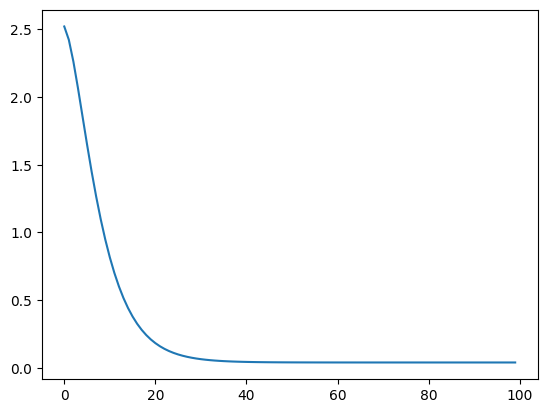

In [496]:
plt.plot(losses)

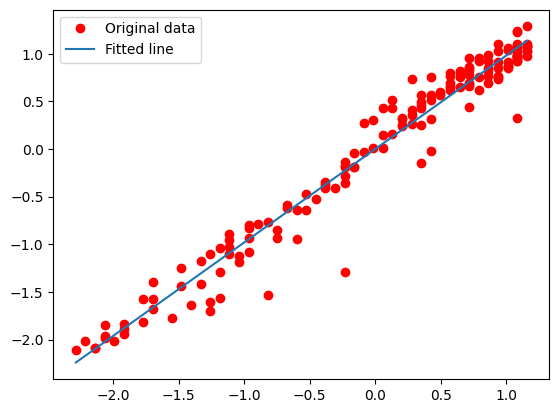

In [498]:
predicted = model(torch.from_numpy(X)).detach().numpy()
plt.plot(X,Y, 'ro', label = 'Original data')
plt.plot(X, predicted, label = 'Fitted line')
plt.legend()
plt.show()

In [499]:
w = model.weight.data.numpy()
w

array([[0.98028797]], dtype=float32)